![Cabecera](../assets/cabecera_sql.png)

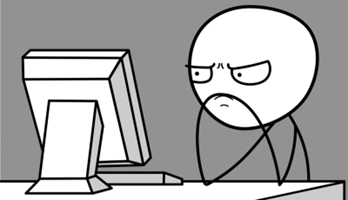

Para ejercitarte y afianzar lo aprendido sobre consultas y queries SQL, completa los siguiente ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  


### Ejercicio 0:

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import sqlite3

Observa la siguiente celda, en ella se usa un nombre especial de bases de datos `:memory:` que en el caso de Sqlite3 lo que hace es crear una base de datos en memoria que desaparece al cerrar la conexión a la misma. Ejecútala:

In [2]:
cnx = sqlite3.connect(':memory:')
cursor_pokemon = cnx.cursor()

### Ejercicio 1

Ahora lee con pandas el fichero csv con ruta "./data/pokemon.csv" y vuelca su contenido en un `DataFrame`. Muestra las primeras líneas y una descripción de su contenido. (Nota:Puede que no te funcione, recuerda que, si es un problema de codificación de caracteres, es posible que necesites usar el argumento `encoding` con valor "latin1" o con otro valor) 

In [3]:
df = pd.read_csv('./data/pokemon.csv', encoding = "latin1")
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,3,False
3,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
4,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,2,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   #          151 non-null    int64 
 1   Name       151 non-null    object
 2   Type 1     151 non-null    object
 3   Type 2     67 non-null     object
 4   Total      151 non-null    int64 
 5   HP         151 non-null    int64 
 6   Attack     151 non-null    int64 
 7   Defense    151 non-null    int64 
 8   Sp. Atk    151 non-null    int64 
 9   Sp. Def    151 non-null    int64 
 10  Speed      151 non-null    int64 
 11  Stage      151 non-null    int64 
 12  Legendary  151 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 14.4+ KB


Una lista de 151 pokemons y sus características bien informadas salvo el campo "Type 2" que tiene pinta de que no todos tienen por qué tenerlo. Habría que preguntar a un experto en Pokemon o bucear en Internet

### Ejercicio 2

Primero, crea una tabla en la base de datos a partir del `DataFrame` del ejercicio anterior ejecutando la siguiente celda: (si se pueden crear tablas desde pandas, ¿se podrán hacer consultas desde pandas?)

In [5]:
# Pasamos el DataFrame de Pandas a SQL
df.to_sql('pokemon', con=cnx, if_exists='append', index=False)


151

Quédate con el nombre que le has dado a la tabla: "pokemon"

Ahora, construye una función como la que has visto en el workout que simplemente haya que pasarle la query en SQL y nos devuelva un dataframe con el resultado de la query:

In [6]:
# Definimos la función para hacer queries.
def sql_query(query):
    cursor_pokemon.execute(query)
    resultado = cursor_pokemon.fetchall()
    columnas = [d[0] for d in cursor_pokemon.description]
    return pd.DataFrame(resultado, columns= columnas)

A partir de aquí emplea la función para resolver el resto de ejercicios

En sesiones posteriores veremos una forma más sencilla de hacer las consultas, por ahora no es malo que trabajes con los cursores.

### Ejercicio 3

3.1 Obten un `DataFrame` con todos los campos a través de una consulta SQL a la tabla de la base de datos que hemos creado en el ejercicio. Limita su salida a los 10 primeros registros.

In [7]:
query = '''
SELECT *
FROM pokemon limit 10;
'''

sql_query(query)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,3,0
3,4,Charmander,Fire,None,309,39,52,43,60,50,65,1,0
4,5,Charmeleon,Fire,None,405,58,64,58,80,65,80,2,0
5,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,3,0
6,7,Squirtle,Water,None,314,44,48,65,50,64,43,1,0
7,8,Wartortle,Water,None,405,59,63,80,65,80,58,2,0
8,9,Blastoise,Water,None,530,79,83,100,85,105,78,3,0
9,10,Caterpie,Bug,None,195,45,30,35,20,20,45,1,0


3.2 Obten un `Dataframe` con los campos "Name", "Type 1", "Type 2". Limita la salida a 10 registros.


In [8]:
query = '''
SELECT Name, "Type 1", "Type 2"
FROM pokemon limit 10;
'''

sql_query(query)

,Name,Type 1,Type 2
0,Bulbasaur,Grass,Poison
1,Ivysaur,Grass,Poison
2,Venusaur,Grass,Poison
3,Charmander,Fire,None
4,Charmeleon,Fire,None
5,Charizard,Fire,Flying
6,Squirtle,Water,None
7,Wartortle,Water,None
8,Blastoise,Water,None
9,Caterpie,Bug,None


3.3  Obten la misma tabla que el apartado anterior, pero en este caso renombrando los campos al castellano.


In [9]:
query = '''
SELECT Name as Nombre, "Type 1" as "Tipo 1", "Type 2" as "Tipo 2"
FROM pokemon limit 5;
'''

sql_query(query)

,Nombre,Tipo 1,Tipo 2
0,Bulbasaur,Grass,Poison
1,Ivysaur,Grass,Poison
2,Venusaur,Grass,Poison
3,Charmander,Fire,None
4,Charmeleon,Fire,None


### Ejercicio 4

Obtén todos los valores diferentes para "Type 1", hazlo a través de una consulta SQL y directamente sobre el `DataFrame` del [ejercicio 1](###Ejercicio-1) usando los métodos de pandas

In [10]:
# SQL
query = '''
SELECT DISTINCT "Type 1"
FROM pokemon;
'''

sql_query(query)

,Type 1
0,Grass
1,Fire
2,Water
3,Bug
4,Normal
5,Poison
6,Electric
7,Ground
8,Fairy
9,Fighting


In [11]:
# Pandas
df["Type 1"].unique()

array(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Poison', 'Electric',
       'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock', 'Ghost', 'Ice',
       'Dragon'], dtype=object)

In [43]:
# Una opcion pandas para sacer exactamente la misma salida
df.groupby("Type 1", as_index = False).count()[["Type 1"]]

,Type 1
0,Bug
1,Dragon
2,Electric
3,Fairy
4,Fighting
5,Fire
6,Ghost
7,Grass
8,Ground
9,Ice


### Ejercicio 5

Obtén el nombre de los Pokemon de agua, a través de una query SQL y de un filtro sobre el `DataFrame`

In [13]:
# SQL
query = '''
SELECT Name
FROM pokemon
WHERE "Type 1" = "Water"
'''

sql_query(query)

,Name
0,Squirtle
1,Wartortle
2,Blastoise
3,Psyduck
4,Golduck
5,Poliwag
6,Poliwhirl
7,Poliwrath
8,Tentacool
9,Tentacruel


In [14]:
# Pandas
df.loc[df["Type 1"] == "Water","Name"]

6        Squirtle
7       Wartortle
8       Blastoise
53        Psyduck
54        Golduck
59        Poliwag
60      Poliwhirl
61      Poliwrath
71      Tentacool
72     Tentacruel
78       Slowpoke
79        Slowbro
85           Seel
86        Dewgong
89       Shellder
90       Cloyster
97         Krabby
98        Kingler
115        Horsea
116        Seadra
117       Goldeen
118       Seaking
119        Staryu
120       Starmie
128      Magikarp
129      Gyarados
130        Lapras
133      Vaporeon
Name: Name, dtype: object

In [15]:
# Pandas como en la salida SQL
df.loc[df["Type 1"] == "Water"][["Name"]]

,Name
6,Squirtle
7,Wartortle
8,Blastoise
53,Psyduck
54,Golduck
59,Poliwag
60,Poliwhirl
61,Poliwrath
71,Tentacool
72,Tentacruel


### Ejercicio 6

Obtén todos los datos de los Pokemon legendarios, a través de SQL y a través del `DataFrame` [Nota puedes usar True o False en las condiciones del WHERE]

In [16]:
# SQL
query = '''
SELECT *
FROM pokemon
WHERE Legendary = True -- equivale a WHERE Legendary;
'''

sql_query(query)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
0,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,1
1,145,Zapdos,Electric,Flying,580,90,90,85,125,90,100,1,1
2,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,1
3,150,Mewtwo,Psychic,None,680,106,110,90,154,90,130,1,1


Observa que los valores True o False los devuelve como 0 o 1

In [17]:
# Pandas
df.loc[df.Legendary]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
143,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,True
144,145,Zapdos,Electric,Flying,580,90,90,85,125,90,100,1,True
145,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,True
149,150,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True


### Ejercicio 7

Obtén una tabla con los pokemon cuyo nombre empieze por "W" y tenga una defensa mayor de 100 puntos, con SQL y con Pandas

In [18]:
# SQL
query = '''
SELECT *
FROM pokemon
WHERE Name like "W%" AND Defense > 100;
'''

sql_query(query)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
0,110,Weezing,Poison,None,490,65,90,120,85,70,60,2,0


In [19]:
# Pandas
condicion_nombre = df.Name.str.match("W.+")
condicion_defensa = df.Defense > 100
df[condicion_nombre & condicion_defensa]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
109,110,Weezing,Poison,NaN,490,65,90,120,85,70,60,2,False


### Ejercicio 8

Obtén una tabla con los pokemon de la primera generación (columna Stage) y o bien que NO sean de "Type 1" psíquicos o bien que tengan una velocidad superior a 130. Hazlo solo con SQL y con Pandas solo como ejercicio extra.

In [20]:
# SQL 
query = '''
SELECT *
FROM pokemon
WHERE stage = 1 and ("Type 1" <> "Psychic" or Speed > 130);
'''

sql_query(query)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,0
1,4,Charmander,Fire,None,309,39,52,43,60,50,65,1,0
2,7,Squirtle,Water,None,314,44,48,65,50,64,43,1,0
3,10,Caterpie,Bug,None,195,45,30,35,20,20,45,1,0
4,13,Weedle,Bug,Poison,195,40,35,30,20,20,50,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,143,Snorlax,Normal,None,540,160,110,65,65,110,30,1,0
70,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,1
71,145,Zapdos,Electric,Flying,580,90,90,85,125,90,100,1,1
72,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,1


In [21]:
# Extra Pandas
condicion_generacion = df.Stage == 1
condicion_tipo1 = df["Type 1"] != "Psychic"
condicion_velocidad = df.Speed > 130
df[condicion_generacion & (condicion_tipo1 | condicion_velocidad)]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
3,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
6,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False
9,10,Caterpie,Bug,NaN,195,45,30,35,20,20,45,1,False
12,13,Weedle,Bug,Poison,195,40,35,30,20,20,50,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,143,Snorlax,Normal,NaN,540,160,110,65,65,110,30,1,False
143,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,True
144,145,Zapdos,Electric,Flying,580,90,90,85,125,90,100,1,True
145,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,True


### Ejercicio 9

Obtén el ataque medio del conjunto de los pokemon, el ataque medio de los pokemon de fuego y la defensa media de los pokemon de hielo. Llama a la columan resultado "Fuerza Media", "Fuerza Media Fuego" y "Defensa Media Hielo", respectivamente. Hazlo con queries SQL separadas, y como ejercico extra, voluntario, con pandas, también como ejercicio extra, investiga como redondear la salida en SQL a 2 decimales.

In [22]:
# SQL Fuerza media (con redondeo)
query = '''
SELECT ROUND(AVG(Attack),2) "Fuerza Media"
FROM pokemon
'''
sql_query(query)

,Fuerza Media
0,72.55


In [23]:
# SQL Fuerza media Fuego (con redondeo)
query = '''
SELECT "Type 1", ROUND(AVG(Attack),2) "Fuerza Media Fuego" -- meetemos el campo "Type 1" para aclarar a que nos referimos
FROM pokemon
WHERE "Type 1" = "Fire"
'''
sql_query(query)

,Type 1,Fuerza Media Fuego
0,Fire,83.92


In [24]:
# SQL Fuerza media Hielo (con redondeo)
query = '''
SELECT "Type 1", ROUND(AVG(Defense),2) "Defensa Media Hielo" -- meetemos el campo "Type 1" para aclarar a que nos referimos
FROM pokemon
WHERE "Type 1" = "Ice"
'''
sql_query(query)

,Type 1,Defensa Media Hielo
0,Ice,67.5


In [25]:
df.loc[df["Type 1"] == "Ice","Defense"].mean()
df.Attack.mean()

72.54966887417218

In [26]:
# Extra, pandas
pd.DataFrame([[df.Attack.mean(),df.loc[df["Type 1"] == "Fire","Attack"].mean(),df.loc[df["Type 1"] == "Ice","Defense"].mean()]],
             columns= ["Fuerza Media Total", "Fuerza Media Fuego", "Defensa Media Hielo" ])

,Fuerza Media Total,Fuerza Media Fuego,Defensa Media Hielo
0,72.549669,83.916667,67.5


In [27]:
# Extra, Extra lo anterior de pandas en SQL (prueba a quitarle el limit)
query = '''
SELECT
    (SELECT AVG(Attack) FROM pokemon) AS "Fuerza Media Total",
    (SELECT AVG(Attack) FROM pokemon WHERE "Type 1" = 'Fire') AS "Fuerza Media Fuego",
    (SELECT AVG(Defense) FROM pokemon WHERE "Type 1"= 'Ice') AS "Defensa Media Hielo"
FROM
    pokemon
LIMIT 1;
'''
sql_query(query)

,Fuerza Media Total,Fuerza Media Fuego,Defensa Media Hielo
0,72.549669,83.916667,67.5


### Ejercicio 10

Obtén la máxima velocidad por "Type 1" con SQL, y como extra voluntario con Pandas

In [28]:
query = '''
SELECT "Type 1", MAX(Speed) "Maxima Velocidad"
FROM pokemon
GROUP BY "Type 1"'''

sql_query(query)

,Type 1,Maxima Velocidad
0,Bug,105
1,Dragon,80
2,Electric,140
3,Fairy,60
4,Fighting,95
5,Fire,105
6,Ghost,110
7,Grass,80
8,Ground,120
9,Ice,95


In [29]:
# En pandas
df.groupby("Type 1")["Speed"].max()


Type 1
Bug         105
Dragon       80
Electric    140
Fairy        60
Fighting     95
Fire        105
Ghost       110
Grass        80
Ground      120
Ice          95
Normal      115
Poison       90
Psychic     130
Rock        130
Water       115
Name: Speed, dtype: int64

In [30]:
# Extra extra, pandas como salida del SQL
df.groupby("Type 1", as_index = False)["Speed"].max().rename(columns = {"Speed": "Maxima Velocidad"})

,Type 1,Maxima Velocidad
0,Bug,105
1,Dragon,80
2,Electric,140
3,Fairy,60
4,Fighting,95
5,Fire,105
6,Ghost,110
7,Grass,80
8,Ground,120
9,Ice,95


### Ejercicio Extra 1

Una subquery es una query que se introduce usa dentro de otra query para obtener un valor de la misma tabla, o de otra tabla con el que se va calcular una condición. Sabiendo esto, intenta obtener el nombre y velocidad de todos los Pokemon cuya velocidad esté por encima de la media con SQL y con Pandas.

In [31]:
# SQL, observa que en esta posible solución la misma subquery se repite en el WHERE y en el propio SELECT, 
# cuando la colocas en el SELECT el resultado de la subqyery se repite para todas las filas obtenidas con 
# la query principal. En la solución extra al ejercicio 9, la consulta SQL que muestra todos los resultados de una vez, 
# empleamos 3 subqueries en el SELECT
query = '''
SELECT Name "Nombre", Speed "Velocidad", (SELECT AVG(Speed) FROM pokemon) "Velocidad Media" -- subquery SELECT AVG...
FROM pokemon
WHERE Speed > (SELECT AVG(Speed) FROM pokemon); -- subquery SELECT AVG...'''

sql_query(query)

,Nombre,Velocidad,Velocidad Media
0,Venusaur,80,68.933775
1,Charmeleon,80,68.933775
2,Charizard,100,68.933775
3,Blastoise,78,68.933775
4,Butterfree,70,68.933775
...,...,...,...
71,Moltres,90,68.933775
72,Dragonair,70,68.933775
73,Dragonite,80,68.933775
74,Mewtwo,130,68.933775


In [32]:
# Pandas
df_resultado  = df[["Name","Speed"]].rename(columns= {"Name": "Nombre","Speed":"Velocidad"})
df_resultado["Velocidad Media"] = df_resultado.Velocidad.mean()
df_resultado.loc[df_resultado.Velocidad > df_resultado["Velocidad Media"]]

,Nombre,Velocidad,Velocidad Media
2,Venusaur,80,68.933775
4,Charmeleon,80,68.933775
5,Charizard,100,68.933775
8,Blastoise,78,68.933775
11,Butterfree,70,68.933775
...,...,...,...
145,Moltres,90,68.933775
147,Dragonair,70,68.933775
148,Dragonite,80,68.933775
149,Mewtwo,130,68.933775


In [44]:
# Pandas version floreo
pd.concat([df.loc[df.Speed > df.Speed.mean(),["Name","Speed"]].rename(columns = {"Name": "Nombre","Speed": "Velocidad"}),
            pd.Series(df.Speed.mean(),index = df.index, name = "Velocidad Media")], axis = 1)

,Nombre,Velocidad,Velocidad Media
2,Venusaur,80.0,68.933775
4,Charmeleon,80.0,68.933775
5,Charizard,100.0,68.933775
8,Blastoise,78.0,68.933775
11,Butterfree,70.0,68.933775
...,...,...,...
137,NaN,NaN,68.933775
138,NaN,NaN,68.933775
139,NaN,NaN,68.933775
142,NaN,NaN,68.933775


### Ejercicio Extra 2
Obtener la fuerza (ataque) media, la cantidad de Pokemon y el mínimo de defensa por tipo y stage. Hazlo con SQL y con pandas

In [34]:
# SQL
query = '''
SELECT "Type 1" AS "Tipo", stage AS "Generacion", AVG(Attack) "Ataque medio", COUNT(Name) "Num Pokemons", MIN(Defense) "Defensa Mínima"
FROM pokemon
GROUP BY "Type 1", stage'''

sql_query(query)

,Tipo,Generacion,Ataque medio,Num Pokemons,Defensa Mínima
0,Bug,1,70.833333,6,30
1,Bug,2,51.250000,4,50
2,Bug,3,67.500000,2,40
3,Dragon,1,64.000000,1,45
4,Dragon,2,84.000000,1,65
5,Dragon,3,134.000000,1,95
6,Electric,1,58.600000,5,40
7,Electric,2,66.250000,4,55
8,Fairy,1,45.000000,1,48
9,Fairy,2,70.000000,1,73


In [35]:
# Pandas
agregaciones = {
    "Attack": "mean",
    "Name": len,
    "Defense": min
}
nuevos_nombres = {
    "Type 1": "Tipo",
    "Stage": "Generacion",
    "Attack": "Ataque Medio",
    "Name": "Num Pokemons",
    "Defense": "Defensa Mínima"
}
df.groupby(["Type 1","Stage"], as_index= False).agg(agregaciones).rename(columns=nuevos_nombres)

C:\Users\Alberto Romero\AppData\Local\Temp\ipykernel_7896\3646386535.py:14: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.groupby(["Type 1","Stage"], as_index= False).agg(agregaciones).rename(columns=nuevos_nombres)


,Tipo,Generacion,Ataque Medio,Num Pokemons,Defensa Mínima
0,Bug,1,70.833333,6,30
1,Bug,2,51.250000,4,50
2,Bug,3,67.500000,2,40
3,Dragon,1,64.000000,1,45
4,Dragon,2,84.000000,1,65
5,Dragon,3,134.000000,1,95
6,Electric,1,58.600000,5,40
7,Electric,2,66.250000,4,55
8,Fairy,1,45.000000,1,48
9,Fairy,2,70.000000,1,73
